# Ch5_Q8
<h3> We will now perform cross-validation on a simulated data set.

In [3]:
import numpy as np
import pandas as pd


### (a) Generate a simulated data set as follows:

In [13]:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)

<h3>In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

n = 100, p = 1\

$
Y_i = \beta_0 + \beta_1 X_i + \beta_2 X_i^2 + \varepsilon_i
$
\
$
\beta_0 = 0, \quad \beta_1 = 1, \quad \beta_2 = -2, \quad \varepsilon_i \sim N(0, 1).
$

### (b) Create a scatterplot of X against Y . Comment on what you find.

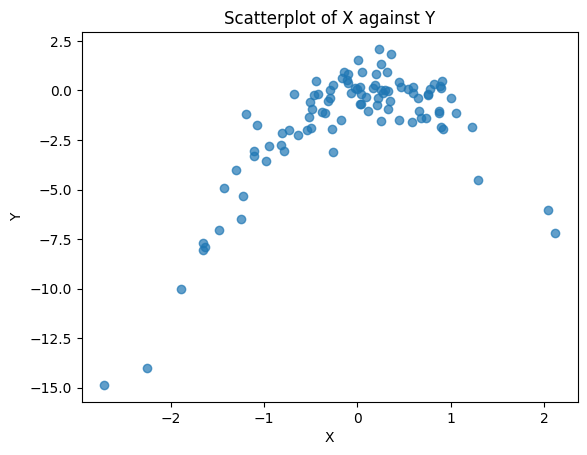

In [14]:
import matplotlib.pyplot as plt

plt.scatter(x, y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X against Y")
plt.show()

The scatterplot of X against Y shows a nonlinear relationship and an inverted U shape curve. When x is close to 0, y increases and reaches its maximum value; otherwise, y decreases.

### (c) Set a random seed, and then compute the LOOCV errors that result from fitting the following four models using least squares:

$
\begin{aligned}
\text{i.} \quad & Y = \beta_0 + \beta_1 X + \varepsilon \\
\text{ii.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon \\
\text{iii.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon \\
\text{iv.} \quad & Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \beta_4 X^4 + \varepsilon
\end{aligned}
$

Note you may find it helpful to use the data.frame() function to create a single data set containing both X and Y .


In [15]:
data = pd.DataFrame({'X': x, 'Y': y})
data.head()

,X,Y
0,0.345584,-0.544554
1,0.821618,0.333950
2,0.330437,-0.013532
3,-1.303157,-4.030442
4,0.905356,0.484861


In [16]:
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import numpy as np

def loocv_error(x, y, degree):
    loo = LeaveOneOut()
    errors = []
    poly = PolynomialFeatures(degree=degree, include_bias=True)

    for train_idx, test_idx in loo.split(x):
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression().fit(X_train_poly, y_train)
        y_pred = model.predict(X_test_poly)

        errors.append((y_test - y_pred) ** 2)

    return np.mean(errors)

In [24]:
X = data[['X']].values
Y = data['Y'].values

for d in range(1, 5):
    error = loocv_error(X, Y, degree=d)
    print(f"Model {d} — LOOCV MSE: {error:.4f}")

Model 1 — LOOCV MSE: 4.2519
Model 2 — LOOCV MSE: 0.9640
Model 3 — LOOCV MSE: 0.9913
Model 4 — LOOCV MSE: 1.0182


### (d) Repeat (c) using another random seed, and report your results. Are your results the same as what you got in (c)? Why?

In [21]:
rng2 = np.random.default_rng(42)
x = rng2.normal(size=100)
y = x - 2 * x**2 + rng2.normal(size=100)

In [25]:
data = pd.DataFrame({'X': x, 'Y': y})
data.head()

,X,Y
0,0.304717,-0.259150
1,-1.039984,-1.903890
2,0.750451,-0.732167
3,0.940565,-0.091244
4,-1.951035,-10.497729


In [26]:
X = data[['X']].values
Y = data['Y'].values

for d in range(1, 5):
    error = loocv_error(X, Y, degree=d)
    print(f"Model {d} — LOOCV MSE: {error:.4f}")

Model 1 — LOOCV MSE: 4.2519
Model 2 — LOOCV MSE: 0.9640
Model 3 — LOOCV MSE: 0.9913
Model 4 — LOOCV MSE: 1.0182


because we use new random seed we will got a new dataset(new x,y and error). we still find the same result that Model 2 got the lowest LOOCV MSE.

### (e) Which of the models in (c) had the smallest LOOCV error? Is this what you expected? Explain your answer.

Model 2: $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \varepsilon $ had the smallest LOOCV error.\
because these data are generated by an underlying quadratic model. Model 1 cannot capture the polynomial relationship of the data, resulting in a higher LOOCV MSE. Models 3 & 4 exhibit overfitting the noise, resulting in higher LOOCV MSEs compared to Model 2.



### (f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using least squares. Do these results agree with the conclusions drawn based on the cross-validation results?

In [29]:
import numpy as np, pandas as pd, statsmodels.api as sm
from statsmodels.formula.api import ols

rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2*x**2 + rng.normal(size=100)
df = pd.DataFrame({'X': x, 'Y': y})

mods = {
    1: 'Y ~ X',
    2: 'Y ~ X + I(X**2)',
    3: 'Y ~ X + I(X**2) + I(X**3)',
    4: 'Y ~ X + I(X**2) + I(X**3) + I(X**4)'
}
results = {d: ols(formula, data=df).fit() for d, formula in mods.items()}

for d, res in results.items():
    print(f'Model {d}')
    print(res.summary().tables[1]) 

Model 1
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4650      0.247     -5.937      0.000      -1.955      -0.975
X              1.9494      0.289      6.752      0.000       1.376       2.522
Model 2
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0728      0.119     -0.611      0.543      -0.309       0.164
X              0.9663      0.126      7.647      0.000       0.715       1.217
I(X ** 2)     -2.0047      0.091    -22.072      0.000      -2.185      -1.824
Model 3
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0572      0.120     -0.477      0.635      -0.295       0.181
X              1.1146      0

model 1: x has a significant positive relationship, but The intercept is significantly negative and coeffcient is -1.465. model 2: both x and x^2 are highly significant, the coeffcient of intercept, x, and x^2 specifically is -0.0728, 0.9663, -2.0047, they are approximately equal to (a) -> $\beta_0 = 0, \quad \beta_1 = 1, \quad \beta_2 = -2 $. mdoel 3: x^3 is not significant, but x & x^2 are still significant, showing no more explanatory power. model 4: x^3 is not significant, x^4 slightly significant, the coeffcient of x^3 and x^4 are very small.

# Ch5_Q9
<h3>We will now consider the Boston housing data set, from the ISLP library.

In [4]:
from ISLP import load_data
import numpy as np
import pandas as pd

Boston = load_data('Boston')
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


### (a) Based on this data set, provide an estimate for the population mean of medv. Call this estimate $\hat{\mu}$.

In [5]:
u_hat = np.mean(Boston['medv'])
u_hat

22.532806324110677

### (b) Provide an estimate of the standard error of $\hat{\mu}$. Interpret this result.
Hint: We can compute the standard error of the sample mean by dividing the sample standard deviation by the square root of the number of observations.

In [6]:
medv = Boston['medv']

n = len(medv)
s = np.std(medv, ddof=1)
se_u = s / np.sqrt(n)
se_u

0.4088611474975351

The estimated mean home value is \( $\hat{\mu}$ = 22.53 \), with a standard error of \( 0.41 \).  
if we repeatedly sampled, the sample mean of `medv` would typically vary by about \$410 around the true population mean.

### (c) Now estimate the standard error of $\hat{\mu}$ using the bootstrap. How does this compare to your answer from (b)?

In [7]:
medv = Boston['medv'].values
n = len(medv)

rng = np.random.default_rng(42)
B = 10000
boot_means = np.empty(B)
for b in range(B):
    idx = rng.integers(0, n, size=n)
    boot_means[b] = medv[idx].mean()

boot_se = boot_means.std(ddof=1)
boot_se

0.4092512845531801

they are very close.

### (d) Based on your bootstrap estimate from (c), provide a 95 % confidence interval for the mean of medv. Compare it to the results obtained by using Boston['medv'].std() and the two standard error rule (3.9).
Hint: You can approximate a 95 % confidence interval using the formula
$
\left[ \hat{\mu} - 2\,\mathrm{SE}(\hat{\mu}), \; \hat{\mu} + 2\,\mathrm{SE}(\hat{\mu}) \right]
$


In [10]:
CI_95_low =  u_hat - 2*boot_se
CI_95_high = u_hat + 2*boot_se

ci = [CI_95_low,CI_95_high]

print(ci)

[21.714303755004316, 23.351308893217038]


use bootstrap estimate: u hat is 22.53, bootstrap SE mean is 0.41, 95% confidence interval is (21.71, 23.35)

In [13]:
std = Boston['medv'].std()
n = Boston['medv'].count()
# standard error u hat
se_u_hat = std/(n**(1/2))
print(std)
print(n)
print(se_u_hat)
# use 2 standard error rule
CI_2ser_low =  u_hat - 2*se_u_hat
CI_2ser_high = u_hat + 2*se_u_hat

ci_2ser = [CI_2ser_low,CI_2ser_high]

print(ci_2ser)

9.19710408737982
506
0.4088611474975351
[21.715084029115605, 23.35052861910575]


use 2 standard error rule: u hat is 22.53, standard error mean is 0.41, 95% confidence interval is (21.72,23.35)

bootstrap standard error ci and 2 standard error ci are identical, because there are 506 observations so that sampling distribution is close enough to normal

### (e) Based on this data set, provide an estimate, $\hat{\mu}_{\text{med}}$, for the median value of medv in the population.

In [14]:
u_med_hat = np.median(Boston['medv'])
u_med_hat

21.2

### (f) We now would like to estimate the standard error of $\hat{\mu}_{\text{med}}$. Unfortunately, there is no simple formula for computing the standard error of the median. Instead, estimate the standard error of the median using the bootstrap. Comment on your findings.

In [16]:
medv = Boston['medv'].values
n = len(medv)

rng = np.random.default_rng(42)
B = 10000
boot_medians = np.empty(B)

for b in range(B):
    sample = rng.choice(medv, size=n, replace=True)
    boot_medians[b] = np.median(sample)

boot_se_med = boot_medians.std(ddof=1)
boot_se_med

0.38034789920208906

we resample many times then the estimated standard error of the median is 0.38, less than se of the mean (0.41). because median is less sensitive to outlier value.

### (g) Based on this data set, provide an estimate for the tenth percentile of medv in Boston census tracts. Call this quantity $\hat{\mu}_{\text{0.1}}$. (You can use the np.percentile() function.)

In [17]:
medv = Boston['medv'].values

u_01_hat = np.percentile(medv, 10)
u_01_hat

12.75

### (h) Use the bootstrap to estimate the standard error of μˆ0.1 percentile() . Comment on your findings.

In [18]:
medv = Boston['medv'].values
n = len(medv)

rng = np.random.default_rng(42)
B = 10000
boot_p10 = np.empty(B)

for b in range(B):
    idx = rng.integers(0, n, size=n)
    sample = medv[idx]
    boot_p10[b] = np.percentile(sample, 10)

boot_se_p10 = boot_p10.std(ddof=1)
boot_est_p10 = np.percentile(medv, 10)

boot_est_p10, boot_se_p10

(12.75, 0.5031575068978646)

the estimated se of 10th percentile is 12.75. bootstrap se of 10th percentile is 0.5. it is higher than se of mean(0.41) and median(0.38). because 10th percentile depend on fewer effective observations